Columns:
Index(['complaint_text', 'department', 'sentiment'], dtype='object')

First 5 rows:
                        complaint_text department sentiment
0   Huge potholes near railway station      Roads  Critical
1  Road completely damaged near market      Roads  Negative
2    Waterlogging making road unusable      Roads  Negative
3     Broken divider causing accidents      Roads  Critical
4       Please repair road near school      Roads   Neutral


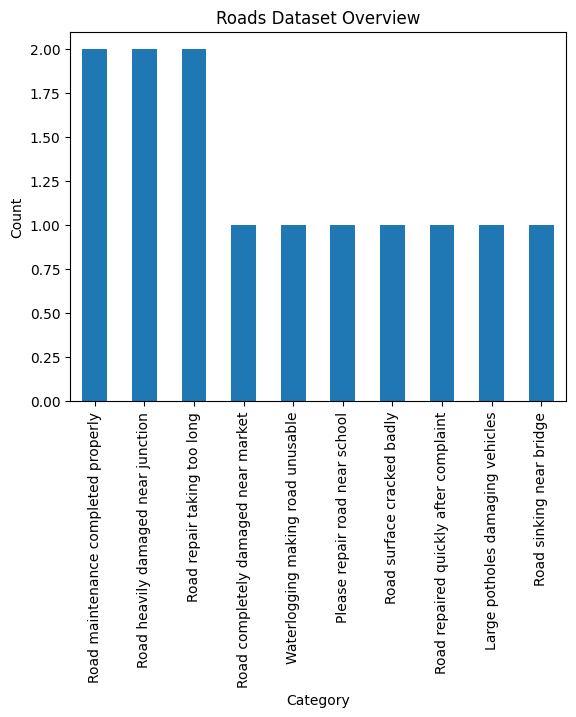

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("roads.csv")

# Show columns and first rows
print("Columns:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())

# Graph
df.iloc[:, 0].value_counts().head(10).plot(kind="bar")

plt.title("Roads Dataset Overview")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [2]:
print(df.columns)
print(df.head())

Index(['complaint_text', 'department', 'sentiment'], dtype='object')
                        complaint_text department sentiment
0   Huge potholes near railway station      Roads  Critical
1  Road completely damaged near market      Roads  Negative
2    Waterlogging making road unusable      Roads  Negative
3     Broken divider causing accidents      Roads  Critical
4       Please repair road near school      Roads   Neutral


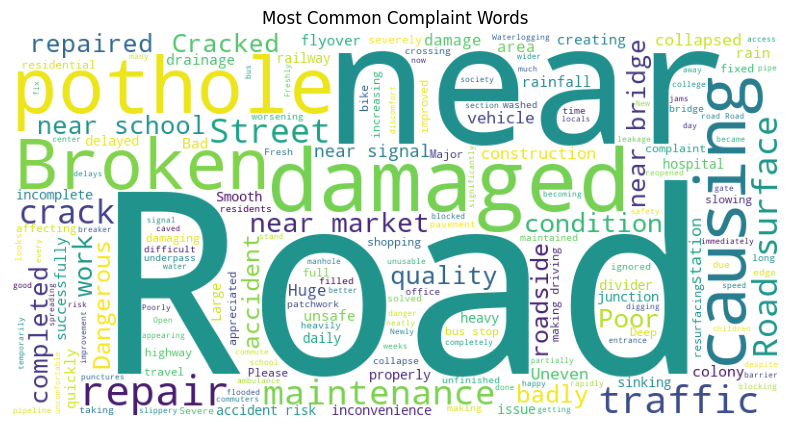

In [3]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all complaints text
text = " ".join(df["complaint_text"])

# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

# Show word cloud
plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Common Complaint Words")
plt.show()

In [4]:
import pandas as pd

# Load dataset
df = pd.read_csv("roads.csv")

print(df.head())

                        complaint_text department sentiment
0   Huge potholes near railway station      Roads  Critical
1  Road completely damaged near market      Roads  Negative
2    Waterlogging making road unusable      Roads  Negative
3     Broken divider causing accidents      Roads  Critical
4       Please repair road near school      Roads   Neutral


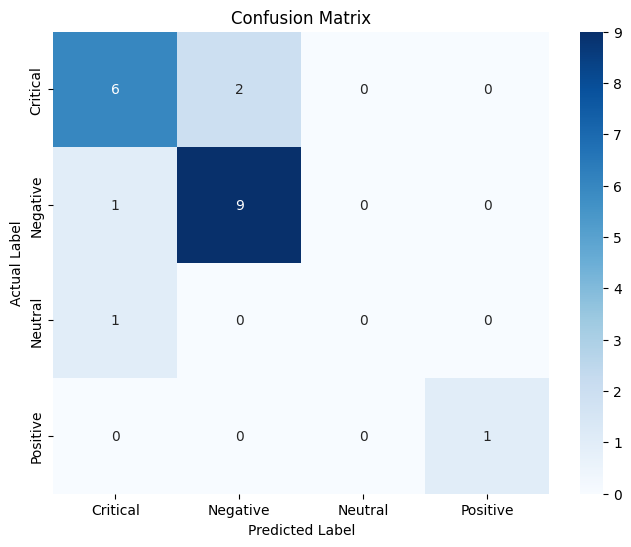

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# Load dataset
df = pd.read_csv("roads.csv")

# Features and target
X = df["complaint_text"]
y = df["sentiment"]

# Convert text into vectors
vectorizer = TfidfVectorizer(
    ngram_range=(1,3),
    stop_words="english",
    max_features=3000
)

X_vectorized = vectorizer.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.1,
    random_state=42
)

# Train model
model = LogisticRegression(
    max_iter=3000,
    C=2,
    solver="lbfgs"
)

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot graph
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

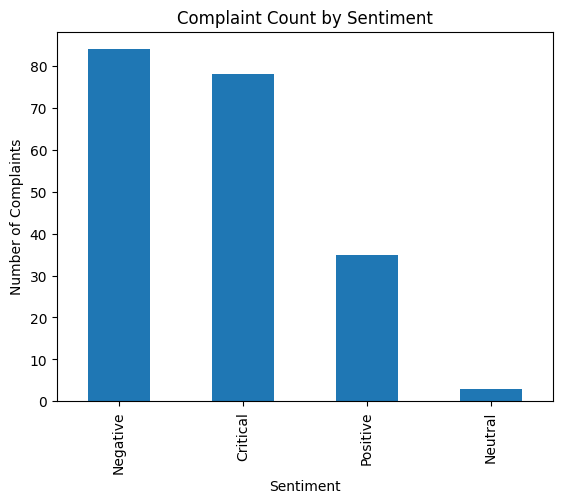

In [6]:
# Complaint count by sentiment
df["sentiment"].value_counts().plot(kind="bar")

plt.title("Complaint Count by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Complaints")

plt.show()

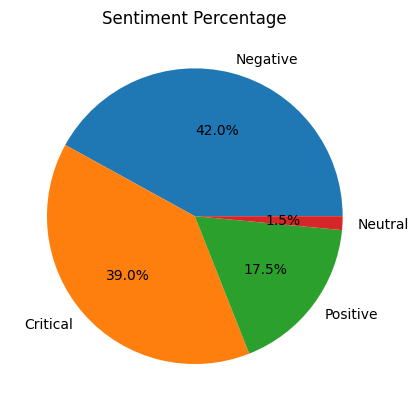

In [7]:
# Pie chart for sentiment distribution
df["sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Sentiment Percentage")
plt.ylabel("")
plt.show()

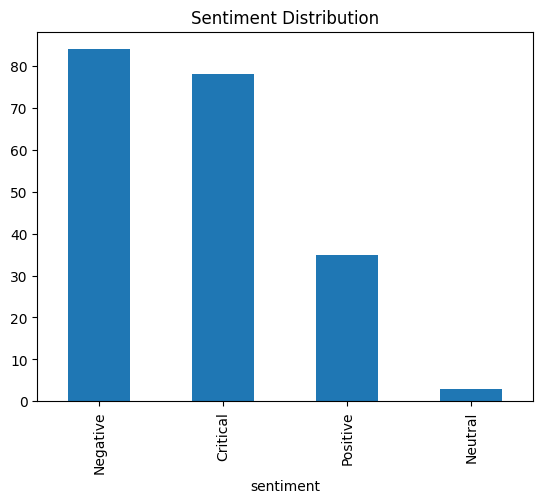

In [8]:
import matplotlib.pyplot as plt

# Count sentiments
df["sentiment"].value_counts().plot(kind="bar")

# Add title
plt.title("Sentiment Distribution")

# Show graph
plt.show()

In [9]:
# Check missing values
df.isnull().sum()

complaint_text    0
department        0
sentiment         0
dtype: int64

In [10]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   complaint_text  200 non-null    object
 1   department      200 non-null    object
 2   sentiment       200 non-null    object
dtypes: object(3)
memory usage: 4.8+ KB


In [11]:
import pandas as pd

# Load dataset
df = pd.read_csv("roads.csv")

# Show first 5 rows
df.head()

,complaint_text,department,sentiment
0,Huge potholes near railway station,Roads,Critical
1,Road completely damaged near market,Roads,Negative
2,Waterlogging making road unusable,Roads,Negative
3,Broken divider causing accidents,Roads,Critical
4,Please repair road near school,Roads,Neutral


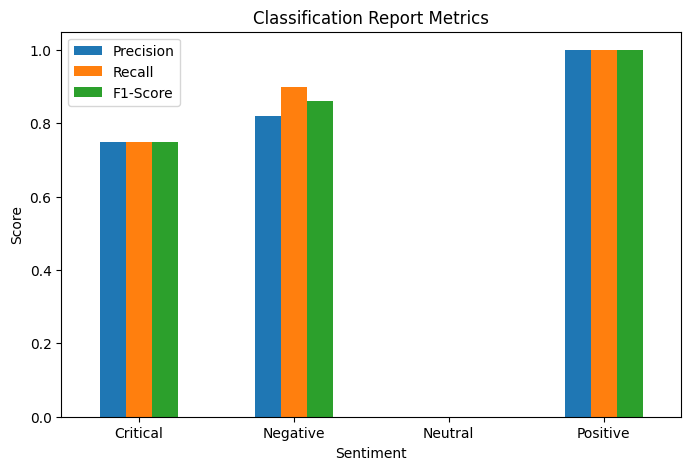

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Classification report values
data = {
    'Sentiment': ['Critical', 'Negative', 'Neutral', 'Positive'],
    'Precision': [0.75, 0.82, 0.00, 1.00],
    'Recall': [0.75, 0.90, 0.00, 1.00],
    'F1-Score': [0.75, 0.86, 0.00, 1.00]
}

df_metrics = pd.DataFrame(data)

# Plot graph
df_metrics.plot(
    x='Sentiment',
    kind='bar',
    figsize=(8,5)
)

plt.title("Classification Report Metrics")
plt.ylabel("Score")
plt.xlabel("Sentiment")
plt.xticks(rotation=0)
plt.show()

In [13]:
print("Jupyter is working")


Jupyter is working


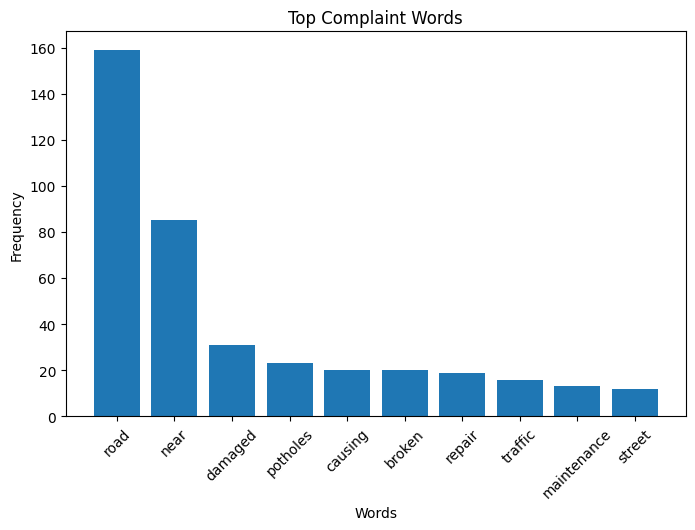

In [14]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import pandas as pd

# Take complaint text column
text_data = df["complaint_text"].dropna()

# Count top words
vectorizer = CountVectorizer(
    stop_words='english',
    max_features=10
)

X = vectorizer.fit_transform(text_data)

# Get words
words = vectorizer.get_feature_names_out()

# Count frequency
counts = X.toarray().sum(axis=0)

# Create dataframe
word_freq = pd.DataFrame({
    'Word': words,
    'Count': counts
})

# Sort highest first
word_freq = word_freq.sort_values(
    by='Count',
    ascending=False
)

# Plot graph
plt.figure(figsize=(8,5))
plt.bar(word_freq['Word'],
        word_freq['Count'])

plt.title("Top Complaint Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()